# Exploratory Data Analysis

**Importing the Dataset**

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "tmdb_5000_credits.csv"
df_credits = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "tmdb/tmdb-movie-metadata",
  file_path,
)

print("First 5 records:", df_credits.head())

file_path2 = "tmdb_5000_movies.csv"

df_movies = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "tmdb/tmdb-movie-metadata",
  file_path2,
)

print("First 5 records:", df_movies.head())

/var/folders/_v/0d3shdb10bvb1sp09bm59gzw0000gn/T/ipykernel_98022/2504145303.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_credits = kagglehub.load_dataset(


First 5 records:    movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  
2  [{"credit_id": "54805967c3a36829b5002c41", "de...  
3  [{"credit_id": "52fe4781c3a36847f81398c3", "de...  
4  [{"credit_id": "52fe479ac

/var/folders/_v/0d3shdb10bvb1sp09bm59gzw0000gn/T/ipykernel_98022/2504145303.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_movies = kagglehub.load_dataset(


First 5 records:       budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  

In [2]:
df = df_movies.merge(df_credits, on="title")

print("Info:")
df.info()
df.describe()

print("\nNumber of null values:")
df.isnull().sum()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status         

budget                     0
genres                     0
homepage                3096
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64

Isolating Genre names

In [3]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast
import pandas as pd

df["genres_parsed"] = df["genres"].apply(ast.literal_eval)
df["genre_names"] = df["genres_parsed"].apply(lambda x: [d["name"] for d in x])

mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df["genre_names"])

encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)
df = pd.concat([df, encoded_df], axis=1)

Isolating Actor Names

In [4]:
df["cast_parsed"] = df["cast"].apply(ast.literal_eval)
df["actor_names"] = df["cast_parsed"].apply(lambda x: [d["name"] for d in x])

Adding release month and year

In [5]:
df["release_date"] = pd.to_datetime(df["release_date"])
df["release_month"] = df["release_date"].dt.month
df["release_year"] = df["release_date"].dt.year

## Exporting the data as CSV

In [6]:
# df.to_csv('movies.csv', index=False)

Movies By Revenue

Revenue amounts


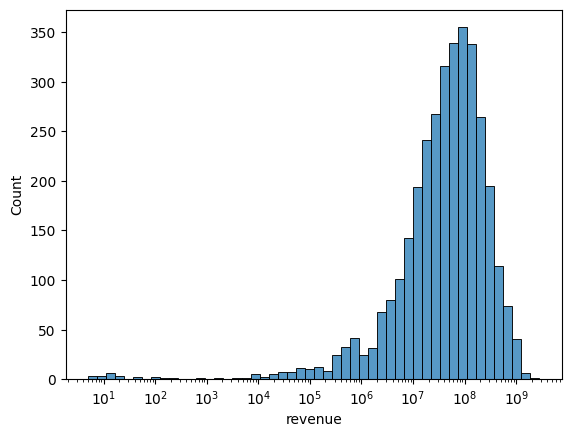

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Revenue amounts")
sns.histplot(data=df, x="revenue", bins=50, log_scale=True)
plt.show()

Revenue plotted against Budget

Budget vs. Revenue


<Axes: xlabel='budget', ylabel='revenue'>

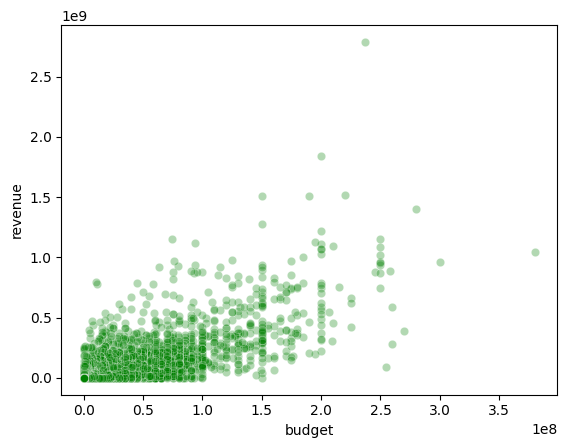

In [8]:
print("Budget vs. Revenue")
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.3, color="green")

Which genre(s) makes the most revenue?
- Adventure
- Action

Genre vs. Revenue


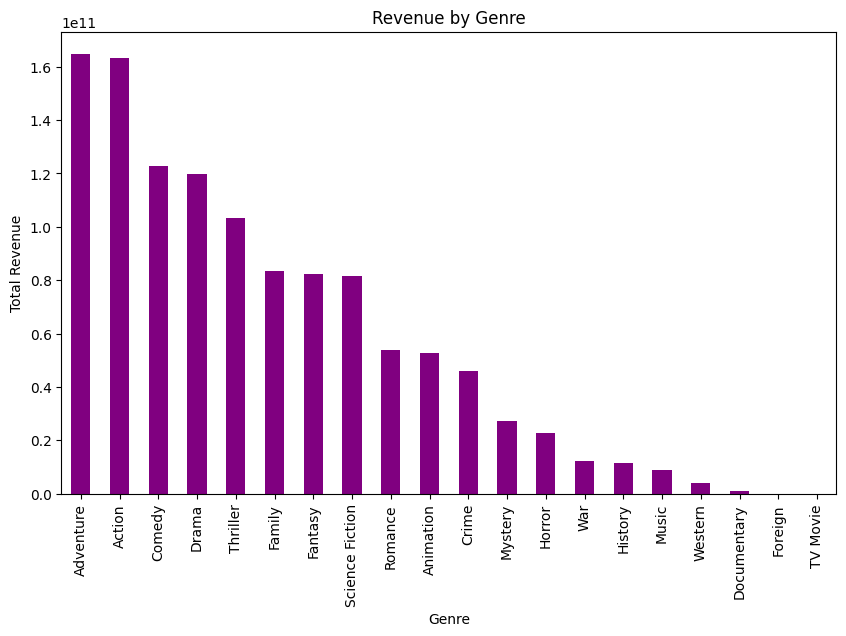

In [9]:
df["genre_names"]
df_exploded = df.explode("genre_names")
df_exploded["genre_names"]
data = df_exploded.groupby("genre_names")["revenue"].sum()
data.sort_values(ascending=False).plot.bar(figsize=(10,6), color="purple")

print("Genre vs. Revenue")
plt.xlabel("Genre")
plt.ylabel("Total Revenue")
plt.title("Revenue by Genre")
plt.show()

Revenue based on number of top actors featured in a movie

Number of Top Actors vs. Revenue


<Axes: xlabel='num_top_actors', ylabel='revenue'>

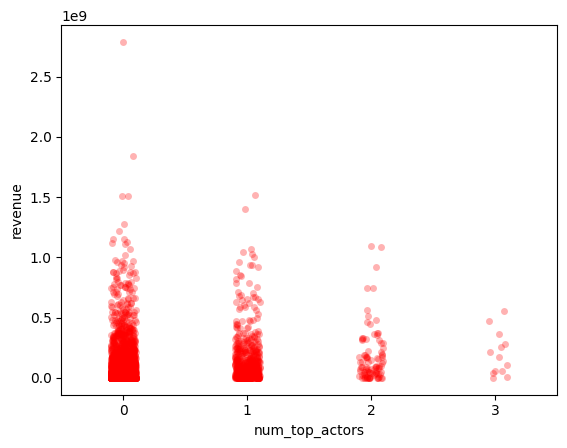

In [10]:
from collections import Counter

all_actors = [actor for sublist in df["actor_names"] for actor in sublist]

actor_counts = Counter(all_actors)
common_20_actors = actor_counts.most_common(20)

top_20_actors = [name[0] for name in actor_counts.most_common(20)]
df["num_top_actors"] = df["actor_names"].apply(
    lambda actors: sum(1 for actor in actors if actor in top_20_actors)
)

print("Number of Top Actors vs. Revenue")
# sns.scatterplot(data=df, x="num_top_actors", y="revenue", alpha=0.3)
sns.stripplot(x="num_top_actors", y="revenue", data=df, alpha=0.3, color="red")

Which release months produce the most revenue?
1. June
2. December
3. May

Release Month vs. Revenue


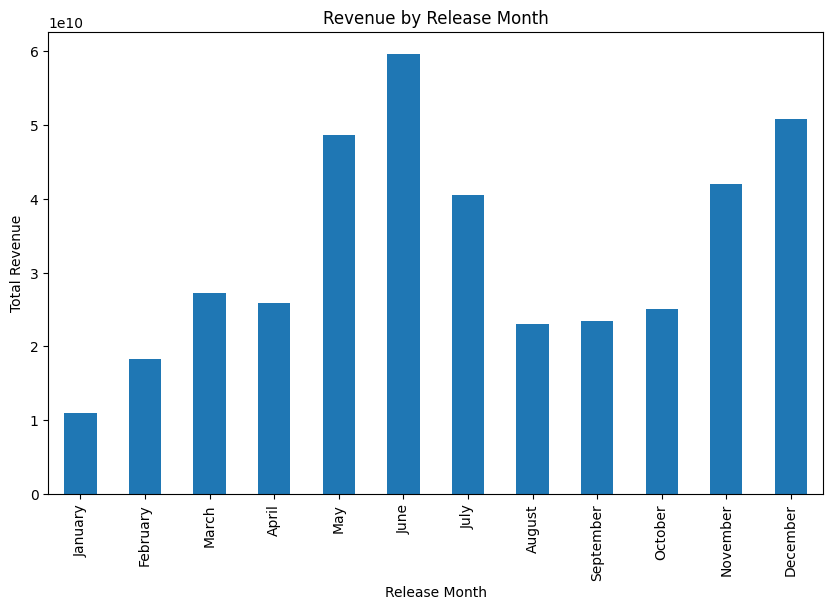

In [11]:

release_month_data = df.groupby("release_month")["revenue"].sum()

mapping_months = {1.0:"January",2.0:"February",3.0:"March",4.0:"April",5.0:"May",6.0:"June",7.0:"July",8.0:"August",9.0:"September",10.0:"October",11.0:"November",12.0:"December",}
release_month_data.index = release_month_data.index.map(mapping_months)
release_month_data.plot.bar(figsize=(10,6))

print("Release Month vs. Revenue")
plt.xlabel("Release Month")
plt.ylabel("Total Revenue")
plt.title("Revenue by Release Month")
plt.show()

In [12]:
# Exporting all features
df.to_csv('../data/eda_movies.csv', index=False)

In [13]:
df["genre_names"] = df["genre_names"].apply(lambda x: x if isinstance(x, list) else [])

df_exploded = df.explode("genre_names")

df_exploded["genre_names"] = df_exploded["genre_names"].str.strip()

df_exploded = df_exploded.rename(columns={"genre_names": "genre"})

df_exploded.to_csv("../data/tableau_data.csv", index=False)